In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir('/content/drive/MyDrive')

['Getting started.pdf',
 'MS Office 2019 Puls.rar',
 'Gmail Password.txt',
 'PORtFoli',
 'PORtFoli.zip',
 'Muhammad Farhan (2).pdf',
 'Muhammad Farhan (1).pdf',
 'WhatsApp Image 2026-05-12 at 4.50.14 PM.jpeg',
 'Classroom',
 'Muhammad Farhan.pdf',
 'Muhammad-Farhan (1).pdf',
 'Muhammad-Farhan.pdf',
 'Colab Notebooks',
 'Muhammad Farhan_CV.pdf',
 'Gun_noGun.zip',
 'No_gun data.zip']

In [4]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/Gun_noGun.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/Gun_noGun')

In [5]:
os.listdir('/content/Gun_noGun')

['2819.jpg',
 '1739.txt',
 '168.jpg',
 '1268.txt',
 '1515.jpg',
 '448.jpg',
 '409.jpg',
 '1371.txt',
 '2717.txt',
 '1855.txt',
 '900.txt',
 '947.jpg',
 '301.jpg',
 '2687.jpg',
 '672.txt',
 '271.jpg',
 '1727.txt',
 '694.txt',
 '685.jpg',
 '2712.jpg',
 '1295.txt',
 '1218.jpg',
 '2120.jpg',
 '1005.jpg',
 '1879.jpg',
 '21.jpg',
 '2159.jpg',
 '2550.txt',
 '1964.txt',
 '467.txt',
 '2156.txt',
 '1971.txt',
 '874.txt',
 '815.txt',
 '1574.txt',
 '1701.txt',
 '2037.txt',
 '1864.jpg',
 '2542.jpg',
 '2439.jpg',
 '1683.jpg',
 '555.txt',
 '738.jpg',
 '421.jpg',
 '660.txt',
 '1963.txt',
 '435.txt',
 '1235.txt',
 '10.txt',
 '548.txt',
 '1000.jpg',
 '978.txt',
 '199.jpg',
 '841.jpg',
 '1.txt',
 '150.jpg',
 '2091.jpg',
 '2209.jpg',
 '305.jpg',
 '675.txt',
 '937.jpg',
 '533.txt',
 '56.txt',
 '1344.jpg',
 '47.txt',
 '2397.txt',
 '2937.jpg',
 '1060.jpg',
 '2109.jpg',
 '1083.txt',
 '858.jpg',
 '1123.txt',
 '2570.txt',
 '136.txt',
 '2811.txt',
 '2114.txt',
 '2342.txt',
 '2191.txt',
 '2709.txt',
 '1863.txt',


In [6]:
folder_path = '/content/Gun_noGun'
all_files = os.listdir(folder_path)

image_files = [f for f in all_files if f.endswith('.jpg')]
print("Total images:", len(image_files))

Total images: 3000


In [7]:
labels = []

In [8]:
for img in image_files:
  txt_file = img.replace('jpg','txt')
  txt_path = os.path.join(folder_path,txt_file)

  if os.path.exists(txt_path):
    with open(txt_path, 'r') as f:
      content = f.read().strip()
      if content:
        labels.append(1)
      else:
        labels.append(0)
  else:
    labels.append(0)

In [9]:
from collections import Counter
print(Counter(labels))

Counter({1: 3000})


In [10]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/No_gun data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/No_gun data')

In [11]:
os.listdir('/content/No_gun data/Final Random Image Dataset')

['Pets', 'Non-Pets']

In [12]:
non_pets_path = '/content/No_gun data/Final Random Image Dataset/Non-Pets'
non_pets_images = os.listdir(non_pets_path)
print("Total Non-Pet images:", len(non_pets_images))

Total Non-Pet images: 4


In [13]:
print(os.listdir(non_pets_path))

['Humans', 'Wild Animals', 'Places', 'Objects']


In [14]:
for folder in ['Wild Animals', 'Humans', 'Objects', 'Places']:
    path = os.path.join(non_pets_path, folder)
    print(folder, ":", len(os.listdir(path)))

Wild Animals : 1000
Humans : 980
Objects : 998
Places : 997


In [15]:
no_gun_images = []

for folder in ['Wild Animals', 'Humans', 'Objects', 'Places']:
    path = os.path.join(non_pets_path, folder)
    for img in os.listdir(path):
        full_path = os.path.join(path, img)
        no_gun_images.append(full_path)

print("Total No Gun images:", len(no_gun_images))

Total No Gun images: 3975


In [16]:
no_gun_images = no_gun_images[:3000]

In [17]:
gun_images = [os.path.join(folder_path, img) for img in image_files]

In [18]:
all_image_paths = gun_images + no_gun_images
all_labels = [1] * len(gun_images) + [0] * len(no_gun_images)

print("Total images:", len(all_image_paths))
print("Total labels:", len(all_labels))

Total images: 6000
Total labels: 6000


In [19]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = 128

X = []
y = []

for path, label in zip(all_image_paths, all_labels):
    img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)
    X.append(img_array)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6000, 128, 128, 3)
y shape: (6000,)


In [20]:
X = X / 255.0

In [21]:
X.min(), X.max()

(np.float32(0.0), np.float32(1.0))

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten

In [24]:
model = keras.Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [27]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.6438 - loss: 0.6311 - val_accuracy: 0.6948 - val_loss: 0.5651
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7727 - loss: 0.4806 - val_accuracy: 0.7521 - val_loss: 0.5024
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7896 - loss: 0.4404 - val_accuracy: 0.7802 - val_loss: 0.4620
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8268 - loss: 0.3868 - val_accuracy: 0.7906 - val_loss: 0.4380
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8466 - loss: 0.3428 - val_accuracy: 0.7677 - val_loss: 0.4694
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8799 - loss: 0.2734 - val_accuracy: 0.7896 - val_loss: 0.4976
Epoch 7/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9258 - loss: 0.1907 - val_accuracy: 0.7958 - val_loss: 0.5785
Epoch 8/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9484 - loss: 0.1363 - val_acc

In [28]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step
Accuracy: 0.7566666666666667
Precision: 0.7319277108433735
Recall: 0.81
F1-Score: 0.7689873417721519
Confusion Matrix:
 [[422 178]
 [114 486]]


In [29]:
from tensorflow.keras.layers import Dropout

In [30]:
model_dropout = keras.Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_dropout = model_dropout.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6555 - loss: 0.6116 - val_accuracy: 0.7510 - val_loss: 0.4971
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7633 - loss: 0.4927 - val_accuracy: 0.7750 - val_loss: 0.4751
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8010 - loss: 0.4384 - val_accuracy: 0.7760 - val_loss: 0.4546
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8141 - loss: 0.4082 - val_accuracy: 0.7667 - val_loss: 0.4783
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8427 - loss: 0.3584 - val_accuracy: 0.7917 - val_loss: 0.4589
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8518 - loss: 0.3279 - val_accuracy: 0.8000 - val_loss: 0.4490
Epoch 7/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8794 - loss: 0.2738 - val_accuracy: 0.8021 - val_loss: 0.4562
Epoch 8/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9039 - loss: 0.2198 - val_accu

In [34]:
y_pred_prob = model_dropout.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [35]:

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.775
Precision: 0.7546296296296297
Recall: 0.815
F1-Score: 0.7836538461538461
Confusion Matrix:
 [[441 159]
 [111 489]]


In [36]:
model2 = keras.Sequential([
    Conv2D(32, (3,3), activation='tanh', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='tanh'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='tanh'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='tanh'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
history2 = model2.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.6292 - loss: 0.6225 - val_accuracy: 0.6875 - val_loss: 0.5743
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7068 - loss: 0.5531 - val_accuracy: 0.7115 - val_loss: 0.5452
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7427 - loss: 0.5201 - val_accuracy: 0.7292 - val_loss: 0.5249
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7529 - loss: 0.5029 - val_accuracy: 0.7292 - val_loss: 0.5350
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7589 - loss: 0.4880 - val_accuracy: 0.7479 - val_loss: 0.5022
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7740 - loss: 0.4708 - val_accuracy: 0.7375 - val_loss: 0.5058
Epoch 7/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7807 - loss: 0.4619 - val_accuracy: 0.7625 - val_loss: 0.4838
Epoch 8/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7844 - loss: 0.4508 - val_accu

In [39]:
y_pred_prob2 = model2.predict(X_test)
y_pred2 = (y_pred_prob2 > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))
print("Recall:", recall_score(y_test, y_pred2))
print("F1-Score:", f1_score(y_test, y_pred2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Accuracy: 0.7725
Precision: 0.7967332123411979
Recall: 0.7316666666666667
F1-Score: 0.7628149435273676
Confusion Matrix:
 [[488 112]
 [161 439]]


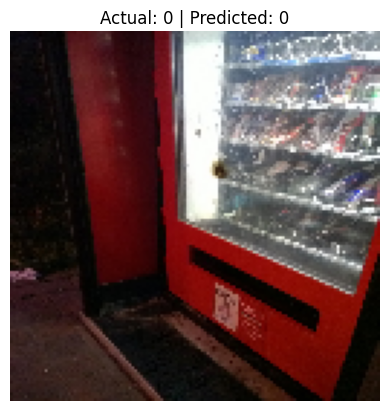

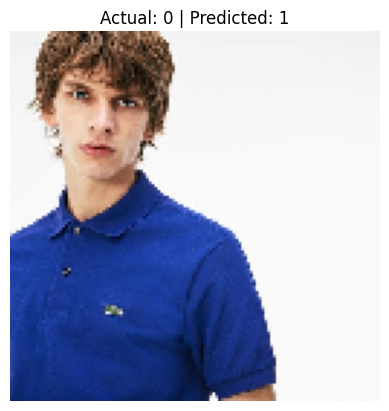

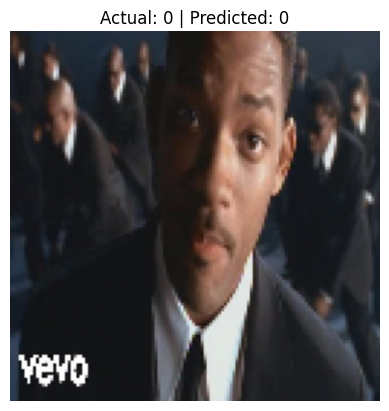

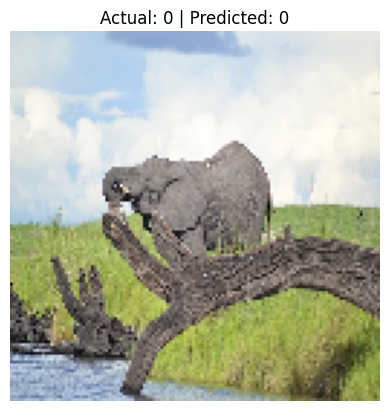

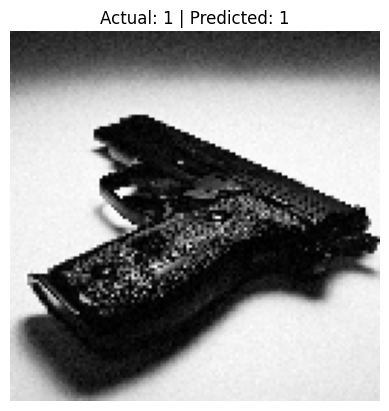

In [43]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(X_test[i])
    plt.title(f"Actual: {y_test[i]} | Predicted: {y_pred[i][0]}")
    plt.axis('off')
    plt.show()

**Conclusion**

Is assignment mein humne CNN (Convolutional Neural Network) ka use karte hue gun aur no-gun images ko classify kiya. Do models train kiye gaye — Model 1 (ReLU activation, Adam optimizer) aur Model 2 (Tanh activation, SGD optimizer), dono mein Dropout layer add ki gayi overfitting kam karne ke liye.

Shuru mein bina Dropout ke model ne severe overfitting dikhai (training accuracy 99.8% jabke validation accuracy sirf ~78%), jo batata hai ke model training data ko memorize kar raha tha unseen data par sahi generalize kiye bina. Dropout layer add karne se ye gap kam hua aur validation performance behtar hui.

Test data par Model 1 (ReLU + Adam) ne behtar overall result diya — Accuracy 77.5%, Precision 75.5%, Recall 81.5%, aur F1-Score 78.4%, jo Model 2 (Accuracy 77.25%, Precision 79.7%, Recall 73.2%, F1-Score 76.3%) se thoda better hai. Khaas kar Recall ke lehaz se Model 1 zyada behtar hai — matlab actual gun images ko pehchanne mein zyada successful raha, jo is tarah ki safety-critical application (weapon detection) ke liye zyada important hai, kyunki ek asli gun ko miss karna ek false alarm se zyada khatarnak hai.

Overall, Model 1 (ReLU + Adam + Dropout) best performing model raha. Future improvement ke liye zyada training data, data augmentation, aur additional regularization techniques use ki ja sakti hain taake overfitting aur kam ho aur model ki reliability behtar ho